# Classificação (binária)

<br>

### Algumas Diferenças entre os problemas Regressão vs. Classificação (tensorflow/Keras):

<br>

| **Componente** | **Problema de Regressão** | **Classificação Binária (0 ou 1)** | **Classificação Multiclasse (ex: 10 dígitos)** |
| --- | --- | --- | --- |
| **Última Camada (`Dense`)** | `Dense(1)` | `Dense(1, activation='sigmoid')` | `Dense(num_classes, activation='softmax')` |
| **Função de Perda (`loss`)** | `'mse'` ou `'mae'` | `'binary_crossentropy'` | `'sparse_categorical_crossentropy'` |
| **Métricas (`metrics`)** | `['mae', 'mse']` | `['accuracy']` | `['accuracy']` |

In [2]:
import warnings

import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential

warnings.filterwarnings('ignore')

<br>

### Base de Dados

In [3]:
dados = load_breast_cancer(as_frame=True)
X = dados.data   # 30 características clínicas (raio, textura, área, etc.)
y = dados.target # 0: Maligno, 1: Benigno

In [6]:
# display(X.head())

display(y.head())

0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64

<br>

### Separação dos dados de Treino e Teste

In [7]:
# (lembram Scikit-Learn)
# Divisão em Treino (80%) e Teste (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

<br>
<br>

### IMPORTANTE PARA REDES NEURAIS: Normalização dos dados!
### Redes neurais aprendem muito melhor se os dados estiverem na mesma escala.


In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

<br>
<br>

### Aqui vamos definir qual a estrura da rede para resolver o problema em questão.

Um detalhe: notem que a camada de entrada não é um neurônio artificial de verdade, funciona mais como um placeholders (não calcula métrias e nem possui função de ativação).

In [9]:
# input_shape=[30] porque temos 30 colunas de entrada
modelo_classificacao = Sequential([
    # Camada Oculta 1: 16 neurônios com ReLU
    Dense(16, activation='relu', input_shape=[30]),
    
    # Camada Oculta 2: 8 neurônios com ReLU
    Dense(8, activation='relu'),
    
    # CAMADA DE SAÍDA PARA CLASSIFICAÇÃO BINÁRIA:
    # 1 neurônio com Sigmoid (gera probabilidade entre 0 e 1)
    Dense(1, activation='sigmoid')
])

W0000 00:00:1787959652.245544  265435 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


<br>

### Compilação do Modelo

In [10]:
modelo_classificacao.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.005),
    loss='binary_crossentropy',  # Função de perda ideal para binário
    metrics=['accuracy']         # Monitoramos a acurácia
)

<br>

### Treinamento
Treinando a Rede Neural de Regressão

In [11]:
print("Treinando a Rede Neural de Classificação...")
historico = modelo_classificacao.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=16,
    verbose=1
)

Treinando a Rede Neural de Classificação...
Epoch 1/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8516 - loss: 0.4508 - val_accuracy: 0.9560 - val_loss: 0.1976
Epoch 2/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9615 - loss: 0.1334 - val_accuracy: 0.9780 - val_loss: 0.0925
Epoch 3/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9725 - loss: 0.0815 - val_accuracy: 0.9890 - val_loss: 0.0592
Epoch 4/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9808 - loss: 0.0635 - val_accuracy: 0.9890 - val_loss: 0.0427
Epoch 5/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9835 - loss: 0.0546 - val_accuracy: 0.9890 - val_loss: 0.0357
Epoch 6/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9835 - loss: 0.0483 - val_accuracy: 0.9890 - val_loss: 0.0342
Epoch 7/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9863 - loss: 0.0418 - val_accuracy: 0.9890 - val_loss: 0.0321
Epoch 8/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9890 - los

print("Treinando a Rede Neural de Classificação...")
historico = modelo_classificacao.fit(
    X_train_scaled, y_train,
    validation_split=0.2, 
    epochs=40,
    batch_size=16,
    verbose=1
)

<br>
<br>

### Podemos avaliar e tentar fazer previsões

In [12]:
# O modelo cospe probabilidades contínuas (ex: 0.94, 0.12)
probabilidades = modelo_classificacao.predict(X_test_scaled).flatten()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


In [13]:
# Convertemos em classes discretas usando o limiar de 0.5
predicoes = (probabilidades >= 0.5).astype(int)

### Avaliação com métricas que já dominamos de ML

In [15]:
print("\nMatriz de confusao")
print(confusion_matrix(y_test, predicoes))


Matriz de confusao
[[41  1]
 [ 3 69]]


In [16]:
print("\nRelatório de classificação")
print(classification_report(y_test, predicoes, target_names=dados.target_names))


Relatório de classificação
              precision    recall  f1-score   support

   malignant       0.93      0.98      0.95        42
      benign       0.99      0.96      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.97      0.96       114
weighted avg       0.97      0.96      0.97       114



In [17]:
tabela_comparacao = pd.DataFrame({
    'Probabilidade': np.round(probabilidades[:7], 3),
    'Classe Prevista': predicoes[:7],
    'Classe Real': y_test.iloc[:7].values
})
print("\nAmostra de Previsões:")
print(tabela_comparacao)


Amostra de Previsões:
   Probabilidade  Classe Prevista  Classe Real
0          0.000                0            0
1          1.000                1            1
2          0.000                0            0
3          0.023                0            1
4          0.000                0            0
5          1.000                1            1
6          1.000                1            1


<br>

---

## O que mudou em relação ao código de Regressão?

* Camada de Saída: Passou de Dense(1) (sem ativação) para Dense(1, activation='sigmoid').
* Loss: Passou de 'mse' para 'binary_crossentropy'.
* Métrica: Passou de ['mae'] para ['accuracy'].

## O comportamento do .predict():

* Na regressão, o .predict() já entregava a resposta final (o preço).
* Na classificação com sigmoid, o .predict() entrega uma probabilidade (de 0 a 1). Nós aplicamos a regra de corte: probabilidades >= 0.5 para transformar em 0 ou 1.

O fluxo train_test_split $\rightarrow$ StandardScaler $\rightarrow$ confusion_matrix é igual o que dominamos em Scikit-Learn. O que muda é a montagem dos blocos no Keras (que pode mudar bastantes)

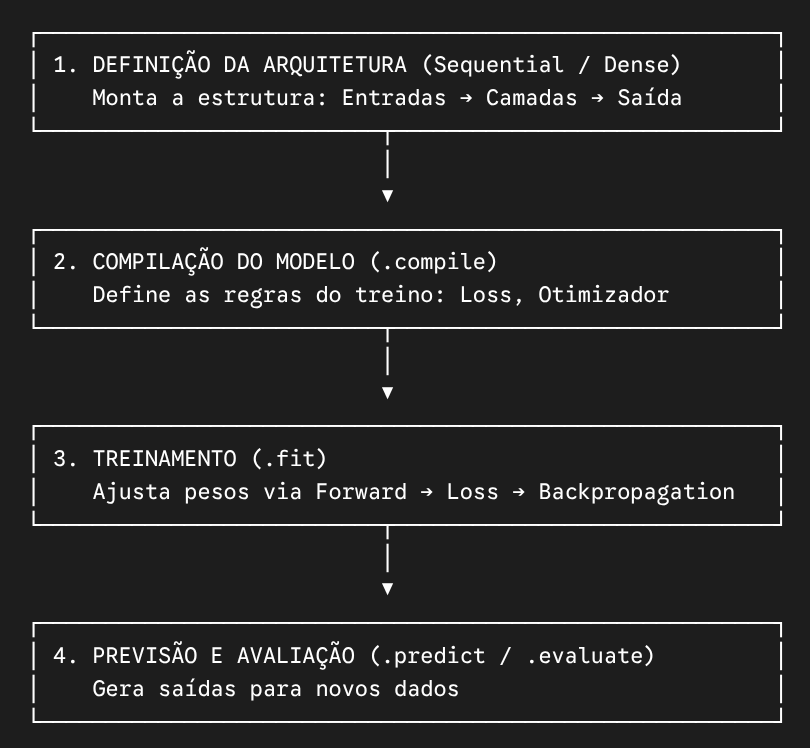


<br>

Notem que cada Neurônio tem uma função de ativação.

#### Cada neurônio individual realiza dois passos matemáticos idênticos:

* Soma Ponderada: Multiplica cada entrada pelo seu respectivo peso e soma o viés ($z = w_1 x_1 + w_2 x_2 + \dots + b$).
* Função de Ativação: Passa esse valor $z$ por uma função não linear ($a = f(z)$) antes de repassar o resultado para a próxima camada.

#### Quando escrevemos Dense(16, activation='relu'), estamos criando 16 neurônios independentes, e cada um deles aplica a ativação ReLU no seu resultado.

Camadas Ocultas (Intermediárias):

* relu: Padrão da indústria/ se buscarem artigos documentações vão ver que é muito utilizada. Zera valores negativos e mantém os positivos. Rápida e evita travamento de gradientes.
* tanh: Mapeia valores entre $-1$ e $+1$. Útil em dados normalizados com média zero.
* Sem ativação (Linear): Se você não passar ativação, a camada inteira vira uma simples multiplicação de matrizes. Várias camadas lineares empilhadas equivalem a uma única camada linear (perde o poder de Deep Learning).

#### Camada de Saída: A ativação aqui é ditada pelo tipo de problema:

* Regressão: Sem ativação (saída livre: $-\infty$ a $+\infty$).
* Classificação Binária: sigmoid (saída entre $0$ e $1$, representando probabilidade).
* Classificação Multiclasse: softmax (distribuição de probabilidades que somam $1.0$).


### Compilação do Modelo (model.compile):

A compilação não treina a rede nem mexe nos dados. Ela apenas configura as "ferramentas matemáticas" que serão usadas durante o aprendizado:

* Função de Perda (Loss Function): O Termômetro do Erro
* Informa à rede como calcular o tamanho do erro a cada lote de dados.
* 'mean_squared_error' (MSE): Para regressão. Penaliza erros grandes ao quadrado.
* 'binary_crossentropy': Para classificação binária ($0$ ou $1$).
* 'categorical_crossentropy' / 'sparse_categorical_crossentropy': Para classificação com $3$ ou mais classes.

### Otimizador (Optimizer): O Mecânico que Ajusta os Peso

* É o algoritmo responsável por calcular os gradientes (derivadas) e decidir como e quanto os pesos ($w$) e vieses ($b$) devem mudar para reduzir a loss.
* 'adam': Otimizador adaptativo padrão. Ajusta a taxa de aprendizado automaticamente para cada peso.
* 'sgd': Gradiente Descendente Estocástico clássico. Mais simples, ajusta os pesos com taxa fixa.

### Métricas (Metrics): O Painel para o Desenvolvedor

* Servem apenas para você acompanhar se o modelo está melhorando em termos humanos (não afetam o cálculo dos gradientes).
* Exemplo: ['accuracy'] para classificação ou ['mae'] para regressão.

### Treinamento (model.fit): O Ciclo de Aprendizado

Nesta etapa, o TensorFlow executa um loop contínuo divido em quatro etapas:

* Forward Pass: Os dados entram na rede, passam pelas somas e funções de ativação, e geram uma previsão $\hat{y}$.
* Cálculo da Loss: A função de perda compara $\hat{y}$ com o valor real $y$ e gera uma pontuação de erro.
* Backward Pass (Backpropagation): O TensorFlow calcula a derivada da perda em relação a cada peso de trás para frente.
* Atualização dos Pesos: O otimizador dá um pequeno passo na direção que reduz o erro, controlado pela taxa de aprendizado (learning rate).

Parâmetros desta fase:

* epochs: Quantas vezes a rede verá todo o conjunto de treino.
* batch_size: Quantas amostras são processadas antes de atualizar os pesos.
* validation_split: Fração dos dados reservada para testar o modelo ao final de cada época sem treinar nele.

### Predição e Avaliação (.predict / .evaluate)

* model.evaluate(X_test, y_test): Roda o modelo no conjunto de teste e devolve os valores finais da loss e das métricas.
* model.predict(X_novo): Executa apenas o Forward Pass em novos dados e entrega a resposta do modelo (números contínuos na regressão ou probabilidades na classificação).


## **Referente a funções de ativação**

- **Camadas Ocultas (Intermediárias):** Usam funções projetadas para permitir que a rede aprenda relações complexas e não lineares sem travar o treinamento.
- **Camada de Saída (Final):** A função é determinada estritamente pelo **formato da resposta** que o seu problema exige (um valor livre, uma probabilidade binária ou uma probabilidade entre várias classes).

### As 5 Principais Funções de Ativação

#### 1. ReLU (*Rectified Linear Unit*) — O Padrão Ouro das Camadas Ocultas

- **Fórmula:** $f(z) = \max(0, z)$
- **Como funciona:** Se a entrada for negativa, a saída é $0$. Se for positiva, a saída é o próprio número.
- **Onde usar:** Praticamente **todas as camadas ocultas** por padrão.
- **Por que usar:** É computacionalmente muito barata e reduz drasticamente o problema do *desaparecimento do gradiente* (*vanishing gradient*), permitindo treinar redes profundas com rapidez.

#### 2. Sigmoid (Logística) — O Mapeador de Probabilidade Binária

- **Fórmula:** $\sigma(z) = \frac{1}{1 + e^{-z}}$
- **Como funciona:** Comprime qualquer valor do eixo real para o intervalo entre **$0.0$ e $1.0$**.
- **Onde usar:** Na **camada de saída** de problemas de **Classificação Binária** (ex: *Spam/Não Spam*, *Doente/Saudável*).
- **Por que NÃO usar nas camadas ocultas:** Para valores muito altos ou muito baixos, a curva achata (derivada quase zero), o que faz o gradiente "sumir" e o modelo parar de aprender.

#### 3. Softmax — A Distribuição de Probabilidade Multiclasse

- **Fórmula:** $\text{Softmax}(z_i) = \frac{e^{z_i}}{\sum_{j} e^{z_j}}$
- **Como funciona:** Pega um vetor de números reais e transforma em probabilidades que **somam exatamente $1.0$ ($100\%$)**.
- **Onde usar:** Na **camada de saída** de problemas de **Classificação Multiclasse** (ex: identificar dígitos de 0 a 9, classificar fotos de 10 animais diferentes).
- **Exemplo:** Se a saída for `[0.70, 0.20, 0.10]`, significa $70\%$ de chance de ser a classe A, $20\%$ a classe B e $10\%$ a classe C.

#### 4. Tanh (Tangente Hiperbólica) — A Versão Centrada em Zero

- **Fórmula:** $\tanh(z) = \frac{e^z - e^{-z}}{e^z + e^{-z}}$
- **Como funciona:** Comprime os valores para o intervalo entre **$-1.0$ e $+1.0$**.
- **Onde usar:** Em algumas camadas ocultas específicas ou modelos sequenciais (como RNNs/LSTMs), especialmente quando os dados de entrada foram normalizados com média zero.
- **Vantagem sobre a Sigmoid:** Por ter média em zero, facilita a convergência dos pesos em relação à Sigmoid.

#### 5. Linear / Sem Ativação (*Identity*)

- **Fórmula:** $f(z) = z$
- **Como funciona:** Não altera o valor gerado pela soma ponderada ($z = w \cdot x + b$).
- **Onde usar:** Na **camada de saída** de problemas de **Regressão** (ex: prever preço de casa, temperatura, vendas).

### Guia Rápido:

| **Posição da Camada** | **Tipo de Problema** | **Função de Ativação Recomendada** | **Exemplo no Keras** |
| --- | --- | --- | --- |
| **Camadas Ocultas** | Qualquer tipo de problema | **`relu`** *(ou variantes como `leaky_relu`)* | `Dense(64, activation='relu')` |
| **Camada de Saída** | Regressão (valor numérico contínuo) | **Linear** *(nenhuma ativação)* | `Dense(1)` |
| **Camada de Saída** | Classificação Binária (2 classes) | **`sigmoid`** | `Dense(1, activation='sigmoid')` |
| **Camada de Saída** | Classificação Multiclasse ($N$ classes) | **`softmax`** | `Dense(N, activation='softmax')` |

<br>

Referência para funções de ativação:

https://medium.com/@alef.mattias/fun%C3%A7%C3%B5es-de-ativa%C3%A7%C3%A3o-em-redes-neurais-d0a5ad9e2f17